<a href="https://colab.research.google.com/github/fddxxueyj/QBO-FNOs/blob/main/FNO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
print(torch.__version__)

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/QBO-FNOs/HamidPahlavan-qbo1d-8e6c775')

from qbo1d import adsolver_new, utils
from qbo1d.stochastic_2wave_forcing import WaveSpectrum

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.autograd import Variable
#from torchinfo import summary

# import netCDF4 as nc
#from prettytable import PrettyTable
import xarray as xr

2.10.0+cu128
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# torch.set_default_dtype(torch.float32)

In [ ]:
rez = 200

In [ ]:
# data = xr.open_dataset('drive/MyDrive/QBO-FNOs/nonlocality/QBO_0.5x_100yrs_' + str(rez) + 'm.nc')
# u = data.u[:-1, 1:-1].values
# f = data.f[1:, 1:-1].values

In [ ]:


# time_in_years = np.arange(u.shape[0]) / 365.0

# height_in_km = np.linspace(17, 35, u.shape[1])
# plt.figure(figsize=(16, 2))

# plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
# plt.colorbar(label='u (m/s)')
# plt.xlabel('Time (years)')
# plt.ylabel('Height (km)')
# plt.title('training data (feature: u)')
# plt.show()

# plt.figure(figsize=(16, 2))
# plt.contourf(time_in_years, height_in_km, f.T, cmap='jet', levels=50)
# plt.colorbar(label='f')
# plt.xlabel('Time (years)')
# plt.ylabel('Height (km)')
# plt.title('training data (value:f, next step)')
# plt.show()


In [ ]:
!ls /content/drive/MyDrive/QBO-FNOs/HamidPahlavan-qbo1d-8e6c775

control.py	   example_nn_emulator.ipynb  models
data		   example_stochastic.ipynb   qbo1d
docs		   figures		      qbo1d-environment-spec-file.txt
example_FNO.ipynb  FNO_solver.ipynb	      README.md
example.ipynb	   LICENSE


In [ ]:
# training data generated from the model
# torch.set_default_dtype(torch.float64)
solver = adsolver_new.ADSolver_new(t_max=360*100*86400)

# z = solver.z
# z_min = solver.z_min
# z_max = solver.z_max

# # Define the new initial condition using a trigonometric function with exponential decay
# A = 30.0 # Example amplitude in m/s
# k = torch.pi / (z_max - z_min) # Wavenumber for one half-wave over the range
# alpha = 2.3025 / (z_max - z_min) # Decay factor such that exp(-alpha * (z_max - z_min)) is approx 0.1

# new_initial_condition = lambda z_val: A * torch.sin(k * (z_val - z_min)) * torch.exp(-alpha * (z_val - z_min))
# solver.initial_condition = new_initial_condition

In [ ]:
# plot the initial condition
def ax_pos_inch_to_absolute(fig_size, ax_pos_inch):
    ax_pos_absolute = []
    ax_pos_absolute.append(ax_pos_inch[0]/fig_size[0])
    ax_pos_absolute.append(ax_pos_inch[1]/fig_size[1])
    ax_pos_absolute.append(ax_pos_inch[2]/fig_size[0])
    ax_pos_absolute.append(ax_pos_inch[3]/fig_size[1])

    return ax_pos_absolute

# u_init = solver.initial_condition(solver.z)
# z = solver.z

# fig_size = (06.90, 02.20 + 01.50)
# fig = plt.figure(figsize=fig_size)

# ax = []

# ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.75, 01.25, 06.00, 02.00])))

# # Calculate min/max for u_init for x-axis limits
# cmin_u = u_init.min().numpy()
# cmax_u = u_init.max().numpy()

# # Set y-axis limits based on z (in Km)
# ymin_z = solver.z_min/1000.
# ymax_z = solver.z_max/1000.

# ax[0].set_xlim(left=cmin_u)
# ax[0].set_xlim(right=cmax_u)
# ax[0].set_ylim(bottom=ymin_z)
# ax[0].set_ylim(top=ymax_z)

# h = []

# h.append(ax[0].plot(u_init.numpy()[:], z[:]/1000)) # Plot u_init on x, z/1000 on y

# ax[0].set_xlabel('u_init (m/s)', fontsize=10)
# ax[0].set_ylabel('Altitude (Km)', fontsize=10)

# ax[0].set_title('Initial Condition (u_init) Profile')

# ax[0].tick_params(which='both', left=True, right=True, bottom=True, top=True)
# ax[0].tick_params(which='both', labelbottom=True)

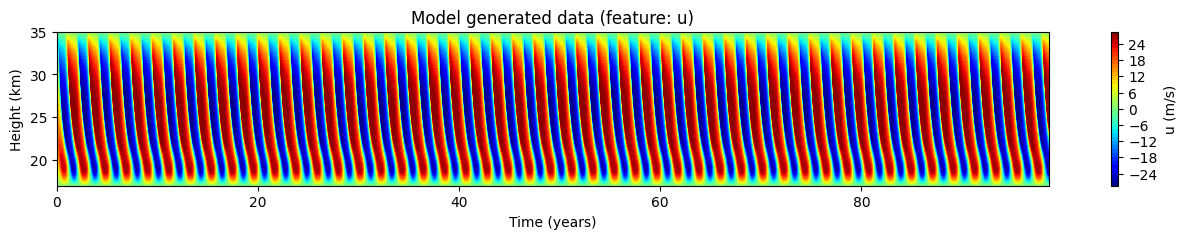

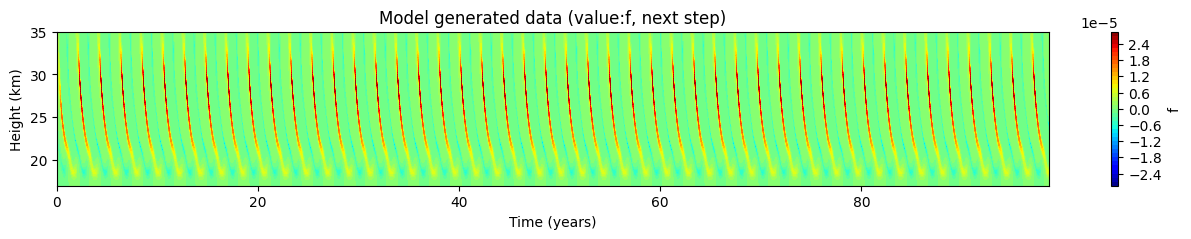

In [ ]:
# gw = WaveSpectrum(
#     solver,
#     ase=6.0e-4,
#     asv=5.0e-12,
#     cse=30.0,
#     csv=64.0,
#     corr=0.5,
#     seed=1234
# )

u, s = solver.solve()

model = utils.load_model(solver)


u_model = u.cpu().numpy()
f_model = f.cpu().numpy()

time_in_years_model = np.arange(u_model.shape[0]) / 365.0
height_in_km_model = np.linspace(17, 35, u_model.shape[1])

plt.figure(figsize=(16, 2))

plt.contourf(time_in_years_model, height_in_km_model, u_model.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('Model generated data (feature: u)')
plt.show()

plt.figure(figsize=(16, 2))
plt.contourf(time_in_years_model, height_in_km_model, f_model.T, cmap='jet', levels=50)
plt.colorbar(label='f')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('Model generated data (value:f, next step)')
plt.show()

In [ ]:
# big data
u = u_model
f = f_model

trainset = TensorDataset(torch.from_numpy(u[:90*365]).float(),torch.from_numpy(f[:90*365]).float())
valset = TensorDataset(torch.from_numpy(u[90*365:]).float(),torch.from_numpy(f[90*365:]).float())

In [ ]:
# trainset = TensorDataset(torch.from_numpy(u[:90*365]).float(),torch.from_numpy(f[:90*365]).float())
# valset = TensorDataset(torch.from_numpy(u[90*365:]).float(),torch.from_numpy(f[90*365:]).float())

In [ ]:
train_dataloader = DataLoader(trainset, batch_size=1000, shuffle=True, num_workers=4)
val_dataloader  = DataLoader(valset, batch_size= len(valset), shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# generate test data
# data = xr.open_dataset('drive/MyDrive/QBO-FNOs/nonlocality/QBO_0.5x_100yrs_' + str(rez) + 'm.nc')
# u = data.u[:-1, 1:-1].values
# f = data.f[1:, 1:-1].values

In [ ]:
# u
# testset = TensorDataset(torch.from_numpy(u).float(),torch.from_numpy(f).float())
# test_dataloader  = DataLoader(testset, batch_size= len(testset), shuffle=False, num_workers=4)

In [ ]:
# Set the device to be used
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
device

device(type='cuda', index=0)

In [ ]:
class GlobalScaler():
    def __init__(self, X):
        self.abs_max = X.std().max() #(0)

    def transform(self, X):
        return X / self.abs_max

    def inverse_transform(self, X):
        return X * self.abs_max

    def to(self, device):
        self.abs_max = self.abs_max.to(device)
        return self

In [ ]:
# -------------------------------------------- FNO architecture -------------------------------------------- #
################################################################
#  1d Fourier Integral Operator
################################################################
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int):
        super(SpectralConv1d, self).__init__()
        """
        Initializes the 1D Fourier layer. It does FFT, linear transform, and Inverse FFT.
        Args:
            in_channels (int): input channels to the FNO layer
            out_channels (int): output channels of the FNO layer
            modes (int): number of Fourier modes to multiply, at most floor(N/2) + 1
        """
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        self.scale = (1 / (in_channels*out_channels))
        self.weights = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        """
        Complex multiplication of the Fourier modes.
        [batch, in_channels, x], [in_channel, out_channels, x] -> [batch, out_channels, x]
            Args:
                input (torch.Tensor): input tensor of size [batch, in_channels, x]
                weights (torch.Tensor): weight tensor of size [in_channels, out_channels, x]
            Returns:
                torch.Tensor: output tensor with shape [batch, out_channels, x]
        """
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Fourier transformation, multiplication of relevant Fourier modes, backtransformation
        Args:
            x (torch.Tensor): input to forward pass os shape [batch, in_channels, x]
        Returns:
            torch.Tensor: output of size [batch, out_channels, x]
        """
        batchsize = x.shape[0]
        # Fourier transformation
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes] = self.compl_mul1d(x_ft[:, :, :self.modes], self.weights)

        #Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

class FNO1d(nn.Module):
    def __init__(self, modes, width, time_future, time_history):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .

        input: a driving function observed at T timesteps + 1 locations (u(1, x), ..., u(T, x),  x).
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """
        self.modes = modes
        self.width = width
        self.time_future = time_future
        self.time_history = time_history
        self.fc0 = nn.Linear(self.time_history+1, self.width)

        self.conv0 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes)
        self.conv3 = SpectralConv1d(self.width, self.width, self.modes)
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)

        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, self.time_future)

    def forward(self, u):
        grid = self.get_grid(u.shape, u.device)
        x = torch.cat((u, grid), dim=-1)
        x = self.fc0(x)
        x = x.permute(0, 2, 1)

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2

        x = x.permute(0, 2, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x = shape[0], shape[1]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1).repeat([batchsize, 1, 1])
        return gridx.to(device)


# -------------------------------------------- Model Parameters --------------------------------------------
time_history = 1 #time steps to be considered as input to the solver
time_future = 1 #time steps to be considered as output of the solver
# device = 'cuda'  #change to cpu of no cuda available

#Model parameters
modes = 9 #18 # 36 # number of Fourier modes to multiply
width = 37 # 37 # input and output channels to the FNO layer

num_epochs = 10 #set to one so faster computation, in principle 20 is best
learning_rate = 1e-4
lr_decay = 0.4
num_workers = 0

model = (FNO1d(modes, width, time_future, time_history)).to(device)

print(sum(p.numel() for p in model.parameters() if p.requires_grad))
# mynet.cuda()

loss = nn.MSELoss()
#use two optimizers.  learing rates seem to work.

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[0, 5, 10, 15], gamma=lr_decay)

batch_size=1000

best_loss = 1e6
train_loss_list = []
test_loss_list = []

60012


In [ ]:
model = model.float()
print(model)

FNO1d(
  (fc0): Linear(in_features=2, out_features=37, bias=True)
  (conv0): SpectralConv1d()
  (conv1): SpectralConv1d()
  (conv2): SpectralConv1d()
  (conv3): SpectralConv1d()
  (w0): Conv1d(37, 37, kernel_size=(1,), stride=(1,))
  (w1): Conv1d(37, 37, kernel_size=(1,), stride=(1,))
  (w2): Conv1d(37, 37, kernel_size=(1,), stride=(1,))
  (w3): Conv1d(37, 37, kernel_size=(1,), stride=(1,))
  (fc1): Linear(in_features=37, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = np.inf

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0

            # save model
            torch.save(model.state_dict(), 'drive/MyDrive/QBO-FNOs/nonlocality/FNOs_model/FNO_4L_9M_w37_0.5x_' + str(rez) + 'm.pth')

        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [ ]:
# training loop
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    avg_loss = 0
    for batch, (X, Y) in enumerate(dataloader):

        X = X.unsqueeze(2).to(device)
        Y = Y.unsqueeze(2).to(device)

        # Compute prediction and loss
        pred = model(X.float())
        loss = loss_fn(pred.float(), scaler_Y.transform(Y).float())

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            avg_loss += loss.item()

    avg_loss /= len(dataloader)

    return avg_loss


# validating loop
def val_loop(dataloader, model, loss_fn):
    avg_loss = 0
    with torch.no_grad():
        for batch, (X, Y) in enumerate(dataloader):

            X = X.unsqueeze(2).to(device)
            Y = Y.unsqueeze(2).to(device)
            # Compute prediction and loss
            pred = model(X.float())
            loss = loss_fn(pred.float(), scaler_Y.transform(Y).float())
            avg_loss += loss.item()

    avg_loss /= len(dataloader)

    return avg_loss

In [ ]:
train_losses = []
val_losses = []

In [ ]:
learning_rate = 1e-2
epochs = 200
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scaler_Y = GlobalScaler(trainset[:][1]).to(device)

In [ ]:
scaler_Y.abs_max

tensor(3.6185e-06, device='cuda:0')

In [ ]:
epochs

200

In [ ]:
# training
k = 0
early_stopper = EarlyStopper(patience=30, min_delta=0.0)
for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, nn.MSELoss(), optimizer)
    train_losses.append(train_loss)
    val_loss = val_loop(val_dataloader, model, nn.MSELoss())
    val_losses.append(val_loss)
    if t % 10 ==0:
        print(f"Epoch {t+1}\n-------------------------------")
        print(val_loss)
        # print(train_loss)
    if early_stopper.early_stop(val_loss):
        if k <8:
            early_stopper = EarlyStopper(patience=40, min_delta=0.0)
            learning_rate = learning_rate * 0.25
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            k += 1
            print("New Learning Rate: " + str(learning_rate))
        else:
            break
print("Done!")

Epoch 1
-------------------------------
0.024208592250943184
Epoch 11
-------------------------------
0.0001969368604477495
Epoch 21
-------------------------------
0.00014557245594915003
Epoch 31
-------------------------------
0.00028016604483127594
Epoch 41
-------------------------------
8.447153959423304e-05
Epoch 51
-------------------------------
0.00014825549442321062
Epoch 61
-------------------------------
3.209723945474252e-05
Epoch 71
-------------------------------
0.00044161599362269044
Epoch 81
-------------------------------
3.750861651496962e-05
Epoch 91
-------------------------------
4.1842689824989066e-05
New Learning Rate: 0.0025
Epoch 101
-------------------------------
3.799617843469605e-05
Epoch 111
-------------------------------
1.9200037058908492e-05
Epoch 121
-------------------------------
1.3816516911902e-05
Epoch 131
-------------------------------
0.00013554483302868903
Epoch 141
-------------------------------
3.615214882302098e-05
Epoch 151
-----------

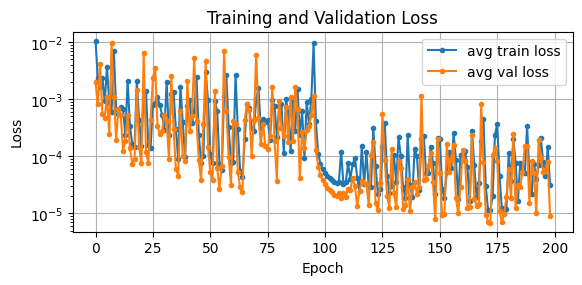

In [ ]:
# def ax_pos_inch_to_absolute(fig_size, ax_pos_inch):
#     ax_pos_absolute = []
#     ax_pos_absolute.append(ax_pos_inch[0]/fig_size[0])
#     ax_pos_absolute.append(ax_pos_inch[1]/fig_size[1])
#     ax_pos_absolute.append(ax_pos_inch[2]/fig_size[0])
#     ax_pos_absolute.append(ax_pos_inch[3]/fig_size[1])

#     return ax_pos_absolute

fig_size = (06.00, 06.00)
fig = plt.figure(figsize=fig_size)

ax = []

ax.append(fig.add_axes(ax_pos_inch_to_absolute(fig_size, [00.60, 00.50, 05.00, 02.00])))

ax[0].plot(train_losses[1:], marker='.', color='C0', label="avg train loss")
ax[0].plot(val_losses[1:], marker='.', color='C1', label="avg val loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_yscale('log')
ax[0].set_title("Training and Validation Loss")
ax[0].grid()
ax[0].legend()

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
class FNO1dAdapter(FNO1d):
    def __init__(self, solver):
        super().__init__(modes=9, width=37, time_future=1, time_history=1)

    def forward(self, u_now):
        u_now = u_now.unsqueeze(0).unsqueeze(-1)
        out = super().forward(u_now)

        return out.squeeze(0).squeeze(-1)

In [ ]:
solver = adsolver_new.ADSolver_new(t_max=360*10*86400)

# gw = WaveSpectrum(
#     solver,
#     ase=6.0e-4,
#     asv=5.0e-12,
#     cse=30.0,
#     csv=64.0,
#     corr=0.5,
#     seed=1234
# )

u_model, s_model = solver.solve()


In [ ]:
np.savetxt('drive/MyDrive/QBO-FNOs/data/u_nonoise_model', u_model)
np.savetxt('drive/MyDrive/QBO-FNOs/data/f_nonoise_model', s_model)

In [ ]:
scaler_Y = GlobalScaler(trainset[:][1]).to(device)

In [ ]:
path_to_state_dict='drive/MyDrive/QBO-FNOs/nonlocality/FNOs_model/FNO_4L_9M_w37_0.5x_' + str(rez) + 'm.pth'

model = FNO1dAdapter(solver)
model.load_state_dict(torch.load(path_to_state_dict, map_location="cpu"))
model.eval()

scaler_Y.abs_max = scaler_Y.abs_max.cpu()

model.scaler_Y = scaler_Y

f_mm = torch.zeros_like(u_model)

with torch.no_grad():
  for i in range(u_model.shape[0]):
    Y = model(u_model[i,:])
    # Y = Y.cpu()
    f_mm[i,:] = scaler_Y.inverse_transform(Y).float()



In [ ]:
def make_source(model, scaler_Y):
    def source_func(u_vec):
        """
        u_vec : tensor (nlev,)
        return: tensor (nlev,)
        """

        with torch.no_grad():
            Y = model(u_vec)

        f = scaler_Y.inverse_transform(Y)

        return f

    return source_func


source_func = make_source(model, scaler_Y)

u, s = solver.solve(source_func=source_func)

In [ ]:
np.savetxt('drive/MyDrive/QBO-FNOs/data/u_nonoise_fno', u)
np.savetxt('drive/MyDrive/QBO-FNOs/data/f_nonoise_fno', s)

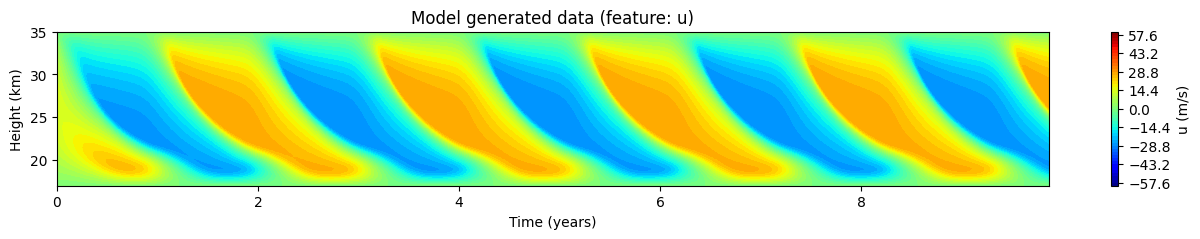

In [ ]:
time_in_years_model = np.arange(u.shape[0]) / 365.0
height_in_km_model = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(16, 2))
levels = np.linspace(-60, 60, 51)
plt.contourf(time_in_years_model, height_in_km_model, u.T, cmap='jet', levels=levels)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('Model generated data (feature: u)')
plt.show()

In [ ]:

u_model = u_model.detach()
f_mm = f_mm.detach()

nu_model = utils.load_model(solver)
f_true = torch.zeros_like(u_model)
for i in range(solver.time.shape[0]):
  f_true[i, :] = nu_model.forward(u_model[i, :])

f = torch.zeros_like(u)
for i in range(solver.time.shape[0]):
  f[i, :] = source_func(u[i, :])


u_model = u_model.cpu().numpy()
f_true = f_true.cpu().numpy()
f_mm = f_mm.cpu().numpy()
f = f.cpu().numpy()

np.savetxt('drive/MyDrive/QBO-FNOs/data/fmm_nonoise_fno', f_mm)

time_stop = 2000
u = u[:time_stop,:]
u_model = u_model[:time_stop,:]
f_true = f_true[:time_stop,:]
f_mm = f_mm[:time_stop,:]
f = f[:time_stop,:]


time_in_years_model = np.arange(u.shape[0]) / 365.0
height_in_km_model = np.linspace(17, 35, u.shape[1])

# plt.figure(figsize=(16, 2))

# plt.contourf(time_in_years_model, height_in_km_model, u.T, cmap='jet', levels=50)
# plt.colorbar(label='u (m/s)')
# plt.xlabel('Time (years)')
# plt.ylabel('Height (km)')
# plt.title('Model generated data (feature: u)')
# plt.show()

# plt.figure(figsize=(16, 2))
# plt.contourf(time_in_years_model, height_in_km_model, f_true.T, cmap='jet', levels=50)
# plt.colorbar(label='f')
# plt.xlabel('Time (years)')
# plt.ylabel('Height (km)')
# plt.title('Model generated data (value:f, next step)')
# plt.show()

# plt.figure(figsize=(16, 2))
# plt.contourf(time_in_years_model, height_in_km_model, f.T, cmap='jet', levels=50)
# plt.colorbar(label='f')
# plt.xlabel('Time (years)')
# plt.ylabel('Height (km)')
# plt.title('Model generated data (value:f, next step)')
# plt.show()

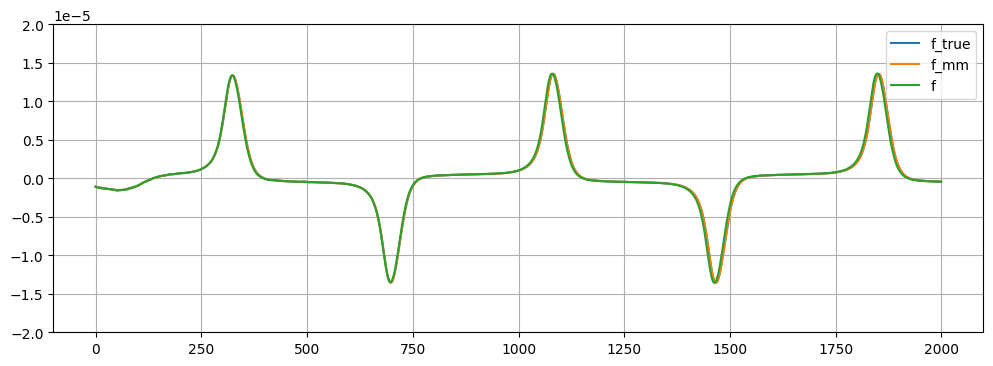

In [ ]:
height = 20

plt.figure(figsize=(12, 4))
plt.plot(f_true[:,height], label='f_true')
plt.plot(f_mm[:,height], label='f_mm')
plt.plot(f[:,height], label='f')
plt.ylim([-2e-5, 2e-5])
plt.legend()
plt.grid()
plt.show()

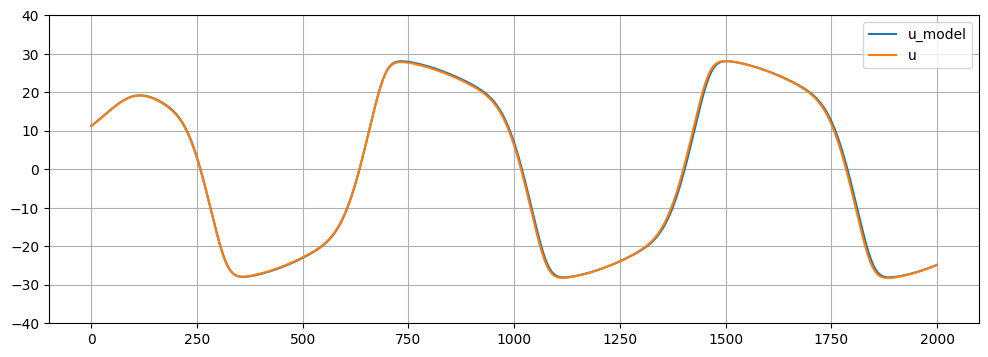

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(u_model[:,height], label='u_model')
plt.plot(u[:,height], label='u')
plt.ylim([-40, 40])
plt.legend()
plt.grid()
plt.show()

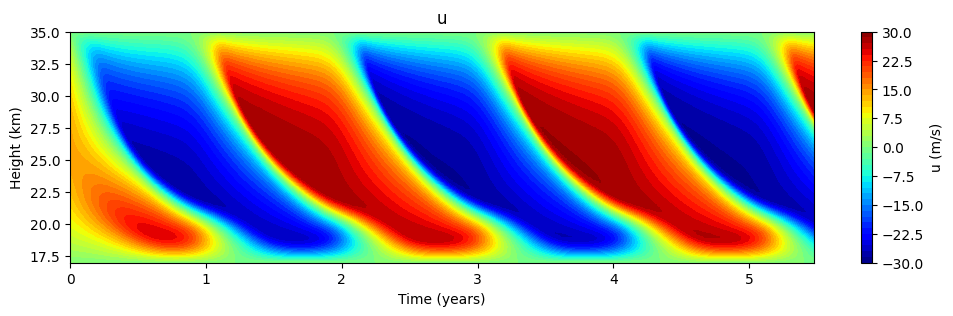

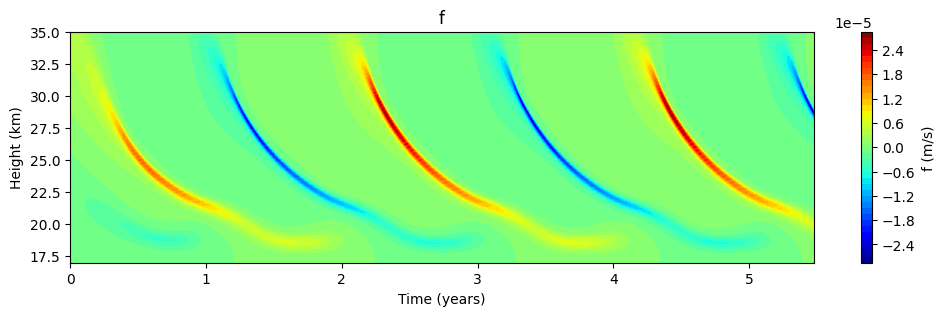

In [ ]:
u = u.detach()

model = utils.load_model(solver)
f = torch.zeros_like(u)
for i in range(f.shape[0]):
    f[i, :] = model.forward(u[i, :])

f = f.detach()

# u = u[:5,:]
# f = f[:5,:]

time_in_years = np.arange(u.shape[0]) / 365.0
height_in_km = np.linspace(17, 35, u.shape[1])

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, u.T, cmap='jet', levels=50)
plt.colorbar(label='u (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('u')
plt.show()

plt.figure(figsize=(12, 3))
plt.contourf(time_in_years, height_in_km, f.T, cmap='jet', levels=50)
plt.colorbar(label='f (m/s)')
plt.xlabel('Time (years)')
plt.ylabel('Height (km)')
plt.title('f')
plt.show()

In [ ]:
rez=100

In [ ]:
solver = adsolver_new.ADSolver_new(t_max=360*100*86400)
u, s = solver.solve()
u += torch.randn_like(u)

u_model = u.cpu().numpy()
f_model = s.cpu().numpy()

time_in_years_model = np.arange(u_model.shape[0]) / 365.0
height_in_km_model = np.linspace(17, 35, u_model.shape[1])

In [ ]:
u = u_model
f = f_model

trainset = TensorDataset(torch.from_numpy(u[:90*365]).float(),torch.from_numpy(f[:90*365]).float())
valset = TensorDataset(torch.from_numpy(u[90*365:]).float(),torch.from_numpy(f[90*365:]).float())

train_dataloader = DataLoader(trainset, batch_size=1000, shuffle=True, num_workers=4)
val_dataloader  = DataLoader(valset, batch_size= len(valset), shuffle=True, num_workers=4)

In [ ]:
# -------------------------------------------- Model Parameters --------------------------------------------
time_history = 1 #time steps to be considered as input to the solver
time_future = 1 #time steps to be considered as output of the solver
# device = 'cuda'  #change to cpu of no cuda available

#Model parameters
modes = 9 #18 # 36 # number of Fourier modes to multiply
width = 37 # 37 # input and output channels to the FNO layer

num_epochs = 10 #set to one so faster computation, in principle 20 is best
learning_rate = 1e-4
lr_decay = 0.4
num_workers = 0

model = (FNO1d(modes, width, time_future, time_history)).to(device)

print(sum(p.numel() for p in model.parameters() if p.requires_grad))
# mynet.cuda()

loss = nn.MSELoss()
#use two optimizers.  learing rates seem to work.

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[0, 5, 10, 15], gamma=lr_decay)

batch_size=1000

best_loss = 1e6
train_loss_list = []
test_loss_list = []

60012


In [ ]:
train_losses = []
val_losses = []

In [ ]:
learning_rate = 1e-2
epochs = 200
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scaler_Y = GlobalScaler(trainset[:][1]).to(device)

In [ ]:
# training
k = 0
early_stopper = EarlyStopper(patience=30, min_delta=0.0)
for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, nn.MSELoss(), optimizer)
    train_losses.append(train_loss)
    val_loss = val_loop(val_dataloader, model, nn.MSELoss())
    val_losses.append(val_loss)
    if t % 10 ==0:
        print(f"Epoch {t+1}\n-------------------------------")
        print(val_loss)
        # print(train_loss)
    if early_stopper.early_stop(val_loss):
        if k <8:
            early_stopper = EarlyStopper(patience=40, min_delta=0.0)
            learning_rate = learning_rate * 0.25
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            k += 1
            print("New Learning Rate: " + str(learning_rate))
        else:
            break
print("Done!")

Epoch 1
-------------------------------
0.06231286749243736
Epoch 11
-------------------------------
0.003902970114722848
Epoch 21
-------------------------------
0.0028784587047994137
Epoch 31
-------------------------------
0.0029024095274508
Epoch 41
-------------------------------
0.004976296331733465
Epoch 51
-------------------------------
0.003788861446082592
Epoch 61
-------------------------------
0.003199497004970908
Epoch 71
-------------------------------
0.003327940823510289
Epoch 81
-------------------------------
0.0027742451056838036
Epoch 91
-------------------------------
0.0022312651854008436
Epoch 101
-------------------------------
0.002300298074260354
New Learning Rate: 0.0025
Epoch 111
-------------------------------
0.0019910577684640884
Epoch 121
-------------------------------
0.0019988222047686577
Epoch 131
-------------------------------
0.002011086791753769
Epoch 141
-------------------------------
0.0021864695008844137
Epoch 151
---------------------------

In [ ]:
solver = adsolver_new.ADSolver_new(t_max=360*10*86400)

u_model, s_model = solver.solve()

In [ ]:
path_to_state_dict='drive/MyDrive/QBO-FNOs/nonlocality/FNOs_model/FNO_4L_9M_w37_0.5x_' + str(rez) + 'm.pth'

model = FNO1dAdapter(solver)
model.load_state_dict(torch.load(path_to_state_dict, map_location="cpu"))
model.eval()

scaler_Y.abs_max = scaler_Y.abs_max.cpu()

model.scaler_Y = scaler_Y

f_mm = torch.zeros_like(u_model)

with torch.no_grad():
  for i in range(u_model.shape[0]):
    Y = model(u_model[i,:])
    # Y = Y.cpu()
    f_mm[i,:] = scaler_Y.inverse_transform(Y).float()

In [ ]:
source_func = make_source(model, scaler_Y)

u, s = solver.solve(source_func=source_func)

In [ ]:
np.savetxt('drive/MyDrive/QBO-FNOs/data/u_noise1_fno', u)
np.savetxt('drive/MyDrive/QBO-FNOs/data/f_noise1_fno', s)

In [ ]:
u_model = u_model.detach()
f_mm = f_mm.detach()

nu_model = utils.load_model(solver)
f_true = torch.zeros_like(u_model)
for i in range(solver.time.shape[0]):
  f_true[i, :] = nu_model.forward(u_model[i, :])

f = torch.zeros_like(u)
for i in range(solver.time.shape[0]):
  f[i, :] = source_func(u[i, :])


u_model = u_model.cpu().numpy()
f_true = f_true.cpu().numpy()
f_mm = f_mm.cpu().numpy()
f = f.cpu().numpy()

np.savetxt('drive/MyDrive/QBO-FNOs/data/fmm_noise1_fno', f_mm)

In [ ]:
rez=500

In [ ]:
solver = adsolver_new.ADSolver_new(t_max=360*100*86400)
gw = WaveSpectrum(solver)

u, s = solver.solve(source_func=gw)
u += torch.randn_like(u)

u_model = u.cpu().numpy()
f_model = s.cpu().numpy()

time_in_years_model = np.arange(u_model.shape[0]) / 365.0
height_in_km_model = np.linspace(17, 35, u_model.shape[1])

In [ ]:
u = u_model
f = f_model

trainset = TensorDataset(torch.from_numpy(u[:90*365]).float(),torch.from_numpy(f[:90*365]).float())
valset = TensorDataset(torch.from_numpy(u[90*365:]).float(),torch.from_numpy(f[90*365:]).float())

train_dataloader = DataLoader(trainset, batch_size=1000, shuffle=True, num_workers=4)
val_dataloader  = DataLoader(valset, batch_size= len(valset), shuffle=True, num_workers=4)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# -------------------------------------------- Model Parameters --------------------------------------------
time_history = 1 #time steps to be considered as input to the solver
time_future = 1 #time steps to be considered as output of the solver
# device = 'cuda'  #change to cpu of no cuda available

#Model parameters
modes = 9 #18 # 36 # number of Fourier modes to multiply
width = 37 # 37 # input and output channels to the FNO layer

num_epochs = 10 #set to one so faster computation, in principle 20 is best
learning_rate = 1e-4
lr_decay = 0.4
num_workers = 0

model = (FNO1d(modes, width, time_future, time_history)).to(device)

print(sum(p.numel() for p in model.parameters() if p.requires_grad))
# mynet.cuda()

loss = nn.MSELoss()
#use two optimizers.  learing rates seem to work.

optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[0, 5, 10, 15], gamma=lr_decay)

batch_size=1000

best_loss = 1e6
train_loss_list = []
test_loss_list = []

60012


In [ ]:
train_losses = []
val_losses = []

In [ ]:
learning_rate = 1e-2
epochs = 200
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scaler_Y = GlobalScaler(trainset[:][1]).to(device)

In [ ]:
# training
k = 0
early_stopper = EarlyStopper(patience=30, min_delta=0.0)
for t in range(epochs):
    train_loss = train_loop(train_dataloader, model, nn.MSELoss(), optimizer)
    train_losses.append(train_loss)
    val_loss = val_loop(val_dataloader, model, nn.MSELoss())
    val_losses.append(val_loss)
    if t % 10 ==0:
        print(f"Epoch {t+1}\n-------------------------------")
        print(val_loss)
        # print(train_loss)
    if early_stopper.early_stop(val_loss):
        if k <8:
            early_stopper = EarlyStopper(patience=40, min_delta=0.0)
            learning_rate = learning_rate * 0.25
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
            k += 1
            print("New Learning Rate: " + str(learning_rate))
        else:
            break
print("Done!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1
-------------------------------
0.2194451242685318
Epoch 11
-------------------------------
0.18466556072235107
Epoch 21
-------------------------------
0.18388871848583221
Epoch 31
-------------------------------
0.18523748219013214
Epoch 41
-------------------------------
0.18300829827785492
Epoch 51
-------------------------------
0.1845276802778244
New Learning Rate: 0.0025
Epoch 61
-------------------------------
0.18155182898044586
Epoch 71
-------------------------------
0.18219421803951263
Epoch 81
-------------------------------
0.18216797709465027
Epoch 91
-------------------------------
0.18245801329612732
Epoch 101
-------------------------------
0.18206825852394104
Epoch 111
-------------------------------
0.18302911520004272
Epoch 121
-------------------------------
0.18223966658115387
New Learning Rate: 0.000625
Epoch 131
-------------------------------
0.18157373368740082
Epoch 141
-------------------------------
0.1819085031747818
Epoch 151
--------------------

In [ ]:
solver = adsolver_new.ADSolver_new(t_max=360*10*86400)
gw = WaveSpectrum(solver)

u_model, s_model = solver.solve(source_func=gw)

In [ ]:
np.savetxt('drive/MyDrive/QBO-FNOs/data/u_noise2_model', u_model)
np.savetxt('drive/MyDrive/QBO-FNOs/data/f_noise2_model', s_model)

In [ ]:
path_to_state_dict='drive/MyDrive/QBO-FNOs/nonlocality/FNOs_model/FNO_4L_9M_w37_0.5x_' + str(rez) + 'm.pth'

model = FNO1dAdapter(solver)
model.load_state_dict(torch.load(path_to_state_dict, map_location="cpu"))
model.eval()

scaler_Y.abs_max = scaler_Y.abs_max.cpu()

model.scaler_Y = scaler_Y

f_mm = torch.zeros_like(u_model)

with torch.no_grad():
  for i in range(u_model.shape[0]):
    Y = model(u_model[i,:])
    # Y = Y.cpu()
    f_mm[i,:] = scaler_Y.inverse_transform(Y).float()

In [ ]:
source_func = make_source(model, scaler_Y)

u, s = solver.solve(source_func=source_func)

In [ ]:
np.savetxt('drive/MyDrive/QBO-FNOs/data/u_noise2_fno', u)
np.savetxt('drive/MyDrive/QBO-FNOs/data/f_noise2_fno', s)

In [ ]:
u_model = u_model.detach()
f_mm = f_mm.detach()

nu_model = utils.load_model(solver)
f_true = torch.zeros_like(u_model)
for i in range(solver.time.shape[0]):
  f_true[i, :] = nu_model.forward(u_model[i, :])

f = torch.zeros_like(u)
for i in range(solver.time.shape[0]):
  f[i, :] = source_func(u[i, :])


u_model = u_model.cpu().numpy()
f_true = f_true.cpu().numpy()
f_mm = f_mm.cpu().numpy()
f = f.cpu().numpy()

np.savetxt('drive/MyDrive/QBO-FNOs/data/fmm_noise2_fno', f_mm)